[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EelcoHoogendoorn/numga/blob/rewrite/rewrite/examples/geometry/cyclides/cyclides.ipynb) [![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/EelcoHoogendoorn/numga?ref=rewrite)

# Dupin Cyclides on the 3-Sphere

This notebook ray traces Dupin cyclides in a curved space, the 3-sphere S³: the unit sphere in four dimensions, seen from inside. Light travels along great circles, the camera and every placement are rotations of R⁴, and there is no point at infinity. The starting point is the spherical cylinder, a tube around a great circle and straight along its core. A conformal dilation bends that core into a small circle, and the tube becomes a Dupin cyclide.

The surfaces are quadrics in conformal geometric algebra. Each pixel's ray is substituted into the surface equation, which gives a polynomial whose nearest root is the hit.

In [1]:
# Setup environment: clone repository and install dependencies if running in Colab
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import os, shutil, subprocess
    os.chdir("/content")  # Always reset to /content
    repo_dir = Path("/content/numga_repo")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "-b", "rewrite", "https://github.com/EelcoHoogendoorn/numga.git", str(repo_dir)], check=True)
    else:
        subprocess.run(["git", "-C", str(repo_dir), "pull", "origin", "rewrite"], check=False)
        for mod in list(sys.modules.keys()):
            if mod.startswith("examples") or mod.startswith("numga"):
                del sys.modules[mod]
    rewrite_dir = repo_dir / "rewrite"
    src_dir = rewrite_dir / "src"
    for p in [str(src_dir), str(rewrite_dir)]:
        if p not in sys.path:
            sys.path.insert(0, p)

# Ensure rewrite root is in sys.path when running locally:
for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / "examples" / "geometry" / "cyclides").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        if str(cand / "src") not in sys.path:
            sys.path.insert(0, str(cand / "src"))
        break
    if (cand / "rewrite" / "examples" / "geometry" / "cyclides").is_dir():
        p = str(cand / "rewrite")
        if p not in sys.path:
            sys.path.insert(0, p)
        if str(cand / "rewrite" / "src") not in sys.path:
            sys.path.insert(0, str(cand / "rewrite" / "src"))
        break

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from numga import Algebra, NumpyContext, stack
from examples.animation import save_animation
from examples.geometry.cyclides import render
from examples.geometry.cyclides.core import pixel_grid, nearest_angle

# The conformal model of S³: the four directions of R⁴, plus one negative direction e.
ga = Algebra("x+y+z+w+e-")
ctx = NumpyContext(ga)
mv = ctx.multivector

Scalar = ga.gatype.scalar()
Sphere = ga.gatype.vector()                   # Grade 1: spheres, and great spheres
Point = ga.gatype.antivector()                # Grade 4: points, the duals of null vectors
Direction = ga.gatype.from_blades("x y z")    # directions at the eye
Quadric = ga.gatype((Sphere, Point))          # polar sphere <- point
PointMap = ga.gatype((Point, Point))

origin: Point = (mv.w + mv.e).dual()          # the eye, at w on S³
antipode: Point = (-mv.w + mv.e).dual()       # the point opposite the eye

# The image: pixel directions at the eye, which looks along -x.
shape = (240, 320)
pixels: Direction = mv(Direction, pixel_grid(shape, np.radians(90))).normalized()   # [n_pixels] Direction

np.set_printoptions(precision=6, suppress=True)

## 1. Points and Spheres

A point of S³ is a unit vector of R⁴, carried as a null vector with one unit of `e` added. A sphere of angular radius `r` about a point is that point's unit vector plus `cos(r)` units of `e`; at a quarter turn the `e` part vanishes, and the sphere is a great sphere. The regressive product `sphere & point` is zero exactly when the point lies on the sphere. `e & point` is the same for every point, and `e` itself is not a point of S³.

In [3]:
# A sphere of angular radius 0.4 about the eye, and the eye turned 0.4 towards x:
radius = 0.4
sphere: Sphere = mv.w + mv.e * np.cos(radius)                                # [] Sphere
turned: Point = (0.5 * radius * (mv.x ^ mv.w)).exp() >> origin               # [] Point

incidence: Scalar = stack((sphere & origin, sphere & turned, mv.e & origin, mv.e & turned))   # [4] Scalar

print("sphere & eye, sphere & turned eye, e & eye, e & turned eye:", incidence.to_array())

sphere & eye, sphere & turned eye, e & eye, e & turned eye: [-0.078939 -0.        1.        1.      ]


## 2. A Ray Is a Great Circle

Turning the eye towards a direction moves it along a great circle. The generator of that turn squares to a negative number, so its exponential sums to a cosine and a sine. The coefficient maps are commutators with the generator: the first and second derivatives of the turning eye.

In [4]:
metric = Direction | Direction                                               # [] Scalar <- (Direction, Direction): d | d
ray_rotation = 0.5 * (Direction ^ mv.w)                                      # [] Bivector <- Direction: turns the eye towards d
ray_linear = ray_rotation.commutator(origin) * 2                             # [] Point <- Direction
ray_quadratic = ray_rotation.commutator(ray_linear) * 2                      # [] Point <- (Direction, Direction)
# The eye turned by t towards a unit d: origin + sin(t) * ray_linear(d) + (1 - cos(t)) * ray_quadratic(d, d)

In [5]:
# checks: a unit direction, followed exactly and along the circle to two angles
direction = mv(Direction, [0.0, 0.6, 0.8])                                   # [] Direction
angles = np.array([0.7, 2.5])
exact: Point = (ray_rotation(direction) * angles).exp() >> origin            # [2] Point
circle: Point = origin + ray_linear(direction) * np.sin(angles) + ray_quadratic(direction, direction) * (1 - np.cos(angles))
reach: Sphere = mv.w + mv.e * np.cos(angles)                                 # [2] Sphere: spheres of radius t about the eye
on_reach: Scalar = stack((reach & exact, reach & circle), axis=-1)           # [2, 2] Scalar

print("exact and circle points on the spheres of radius t:\n", on_reach.to_array())

exact and circle points on the spheres of radius t:
 [[-0.  0.]
 [-0. -0.]]


Points are only defined up to scale. Multiplied by `1 + u**2`, with the half angle `u = tan(t / 2)`, the circle becomes a parabola in `u`, and its bend is the antipode of the eye.

In [6]:
ray_bend = origin * metric + ray_quadratic * 2                               # [] Point <- (Direction, Direction): the antipode, for unit d
# (1 + u**2) * (the eye turned by t) == origin + 2 * u * ray_linear(d) + u**2 * ray_bend(d, d)

In [7]:
# checks: the bend is the antipode, and the parabola in u lands on the circle
u = np.tan(angles / 2)
parabola: Point = origin + ray_linear(direction) * (2 * u) + ray_bend(direction, direction) * u**2   # [2] Point
probes: Sphere = stack((mv.x, mv.y, mv.z, mv.w, mv.e))                      # [5] Sphere
bend_gap: Scalar = probes & (ray_bend(direction, direction) - antipode)     # [5] Scalar
parabola_gap: Scalar = probes[:, None] & (parabola / (1 + u**2) - circle)   # [5, 2] Scalar

print("bend - antipode against five spheres:", bend_gap.to_array())
print("parabola / (1 + u**2) - circle:\n", parabola_gap.to_array())

bend - antipode against five spheres: [0. 0. 0. 0. 0.]
parabola / (1 + u**2) - circle:
 [[ 0.  0.]
 [ 0.  0.]
 [ 0. -0.]
 [ 0.  0.]
 [ 0. -0.]]


## 3. Tracing the Spherical Cylinder

A quadric is a sum of dyads, one per sphere, with weights. As an extensor `Sphere <- Point` it sends a point to its polar sphere, and the point lies on the surface when it is incident with that polar. Each dyad contributes the squared incidence with its sphere.

The simplest one to trace is the spherical cylinder: all points at a fixed angle from a great circle, straight along its core. Two great spheres and `e` build it.

In [8]:
# All points at angle 0.3 from the great circle in the xy plane: z**2 + w**2 == sin(0.3)**2.
tube = 0.3
cylinder: Quadric = mv.z * (mv.z & Point) + mv.w * (mv.w & Point) - np.sin(tube)**2 * mv.e * (mv.e & Point)

# Place it with rotations of R⁴: stand its core up in the image, then bring it within 1.2 rad of the eye.
place = (mv.xw * ((np.pi / 2 - 1.2) / 2)).exp() * (mv.yz * ((np.pi / 2 - 0.3) / 2)).exp()   # [] Motor
placed: Quadric = (place >> cylinder(place << Point)).reshape(1)             # [1] Sphere <- Point

To trace, put each pixel's ray into the surface equation. The eye stays at `w`, so camera coordinates are world coordinates and the camera map is the identity. Along the parabola in `u` the equation is a polynomial of degree four in `u`, with one coefficient form per power and one direction slot per power.

`nearest_angle` solves for `u` and returns the smallest angle along the whole circle, so a ray that passes the antipode keeps going. At the hit, the polar sphere is the tangent sphere, and its length is the length of the surface gradient: the gradient along the ray's unit velocity over that length is the cosine between the ray and the normal. The function below does this for a batch of surfaces, and the later sections reuse it.

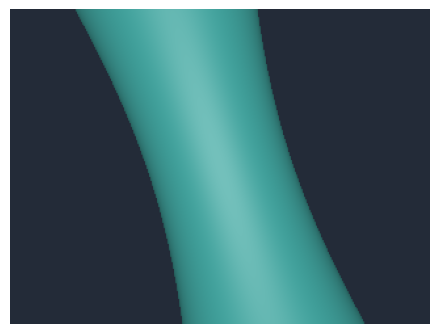

In [9]:
camera_map: PointMap = mv.rotor() >> Point                                   # [] Point <- Point

def trace(surfaces: Quadric):
    form = camera_map & surfaces(camera_map)                                 # [n] Scalar <- (Point, Point): zero on the surface

    # form(X, X) along X = origin + 2 * u * ray_linear(d) + u**2 * ray_bend(d, d), one form per power of u:
    constant = form(origin, origin)                                          # [n] Scalar
    linear = 4 * form(origin, ray_linear)                                    # [n] Scalar <- Direction
    quadratic = 4 * form(ray_linear, ray_linear) + 2 * form(origin, ray_bend)   # [n] Scalar <- (Direction, Direction)
    cubic = 4 * form(ray_linear, ray_bend)                                   # [n] Scalar <- (Direction, Direction, Direction)
    quartic = form(ray_bend, ray_bend)                                       # [n] Scalar <- (Direction, Direction, Direction, Direction)

    # Nearest hit along every great circle; [:, None] puts the surfaces on the first axis, the pixels on the second:
    angle = nearest_angle(
        constant[:, None], 
        linear[:, None](pixels), 
        quadratic[:, None](pixels, pixels),
        cubic[:, None](pixels, pixels, pixels), 
        quartic[:, None](pixels, pixels, pixels, pixels))   # [n, n_pixels] t, inf on a miss
    visible = np.isfinite(angle)
    t = np.where(visible, angle, 0.0)
    hit = origin + ray_linear(pixels) * np.sin(t) + ray_quadratic(pixels, pixels) * (1 - np.cos(t))   # [n, n_pixels] Point
    velocity = ray_linear(pixels) * np.cos(t) + ray_quadratic(pixels, pixels) * np.sin(t)          # [n, n_pixels] unit speed

    # Headlight: the cosine between the ray and the surface normal.
    polar = surfaces[:, None](hit)                                           # [n, n_pixels] Sphere
    facing = -(polar & velocity) / (polar | polar).abs().square_root()       # [n, n_pixels] Scalar
    return facing, visible

facing, visible = trace(placed)
render.draw_facing(facing, visible, shape);

## 4. Bending the Core: Tori

A dilation, the exponential of `toward ^ e` for a point `toward`, is a conformal map of S³ that pushes points towards `toward` and keeps it and its antipode fixed. It acts on a quadric as a sandwich, on the output sphere and on the input point. Dilating towards `z`, a quarter turn from every point of the core, bends the core evenly into a smaller circle, and the cylinder becomes a torus. Seen from `z` a dilation is a uniform scaling, so it only sizes the torus; the tube sets its shape.

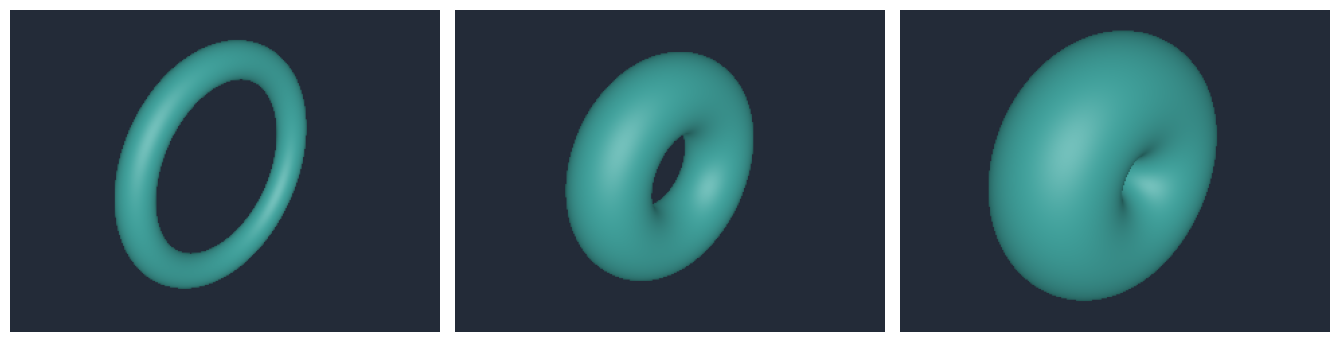

In [10]:
# Turn a point `toward` onto the point `ahead` rad in front of the eye, after a tilt that keeps it fixed.
def placement(toward: Sphere, ahead: float, tilt: float):
    target = mv.w * np.cos(ahead) - mv.x * np.sin(ahead)                     # [] Sphere: a point of S³ as a unit vector
    return (1 + target * toward).normalized() * (mv.yw * (tilt / 2)).exp()   # [] Motor

# Tubes of 0.15, 0.5 and 0.9 rad about the core, each dilated towards z by a strength that frames it:
tubes = np.array([0.15, 0.5, 0.9])
strengths = np.array([1.55, 2.0, 2.4])
tubes_around_core: Quadric = (mv.z * (mv.z & Point) + mv.w * (mv.w & Point)
                              - np.sin(tubes)**2 * mv.e * (mv.e & Point))   # [3] Sphere <- Point
dilations = ((mv.z ^ mv.e) * (strengths / 2)).exp()                          # [3] Motor
views = placement(mv.z, 1.1, 0.8)                                            # [] Motor
place = views * dilations                                                    # [3] Motor
tori: Quadric = place >> tubes_around_core(place << Point)                   # [3] Sphere <- Point

facing, visible = trace(tori)
render.draw_facing(facing, visible, shape);

## 5. Dupin Cyclides

Aiming the dilation at a point near the core breaks the spin symmetry. The tube is compressed on the side of the aim and swells on the other: the lopsided Dupin cyclides.

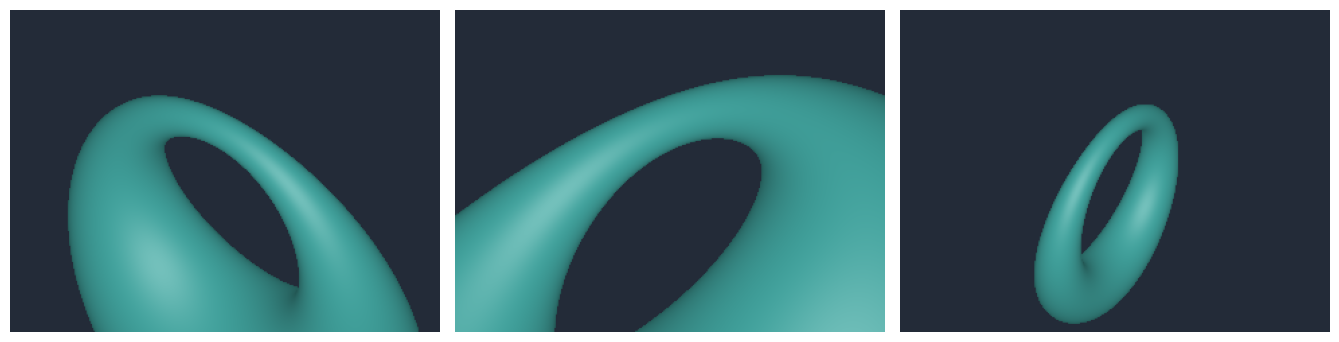

In [11]:
# Tube radius, dilation strength, and how far the aim leans from z towards the core point x:
tubes = np.array([0.25, 0.3, 0.2])
strengths = np.array([1.5, 1.2, 1.8])
leans = np.array([0.7, 0.8, 0.5])
aims: Sphere = mv.z * np.cos(leans) + mv.x * np.sin(leans)                   # [3] Sphere: points of S³ as unit vectors
tubes_around_core: Quadric = (mv.z * (mv.z & Point) + mv.w * (mv.w & Point)
                              - np.sin(tubes)**2 * mv.e * (mv.e & Point))   # [3] Sphere <- Point
dilations = ((aims ^ mv.e) * (strengths / 2)).exp()                             # [3] Motor
lopsided: Quadric = dilations >> tubes_around_core(dilations << Point)            # [3] Sphere <- Point
views = placement(aims, np.array([1.2, 1.3, 1.1]), np.array([-0.7, 0.6, 1.0]))   # [3] Motor
placed_lopsided: Quadric = views >> lopsided(views << Point)                 # [3] Sphere <- Point

facing, visible = trace(placed_lopsided)
render.draw_facing(facing, visible, shape);

## 6. The Conical Case: Vertices, Lemons and Bananas

A spherical cone is the set of points whose geodesic from a vertex makes a fixed angle with an axis. It is built from two great spheres and `e`, like the cylinder. Its geodesics from the vertex meet again at the vertex's antipode, so the cone has two vertices. A strong dilation towards the axis point, a quarter turn from both vertices, pulls the vertices together and closes the cone into a spindle cyclide: two conical points joined by an outer and an inner sheet. Leaning the dilation off the axis bends the inner sheet into a banana, seen through an opening next to one vertex.

In [12]:
# A cone with vertex z, its axis towards x, half-opening 0.35 rad; its geodesics from z meet again at -z.
opening = 0.35
cone: Quadric = mv.x * (mv.x & Point) + np.cos(opening)**2 * (mv.z * (mv.z & Point) - mv.e * (mv.e & Point))

# Dilate towards the axis point x, and leaning 0.7 rad towards y:
leans = np.array([0.0, 0.7])
aims: Sphere = mv.x * np.cos(leans) + mv.y * np.sin(leans)                   # [2] Sphere: points of S³ as unit vectors
dilations = ((aims ^ mv.e) * (3.0 / 2)).exp()                                   # [2] Motor
spindles: Quadric = dilations >> cone(dilations << Point)                          # [2] Sphere <- Point

# The midpoint of the two dilated vertices, where the eye aims:
vertices: Sphere = dilations[:, None] >> stack((mv.z + mv.e, -mv.z + mv.e))    # [2, 2] Sphere: null vectors
unit_e = vertices / -(vertices | mv.e)                                       # [2, 2] Sphere: one unit of e each
midpoints: Sphere = (unit_e[:, 0] + unit_e[:, 1] - 2 * mv.e).normalized()   # [2] Sphere: points of S³ as unit vectors

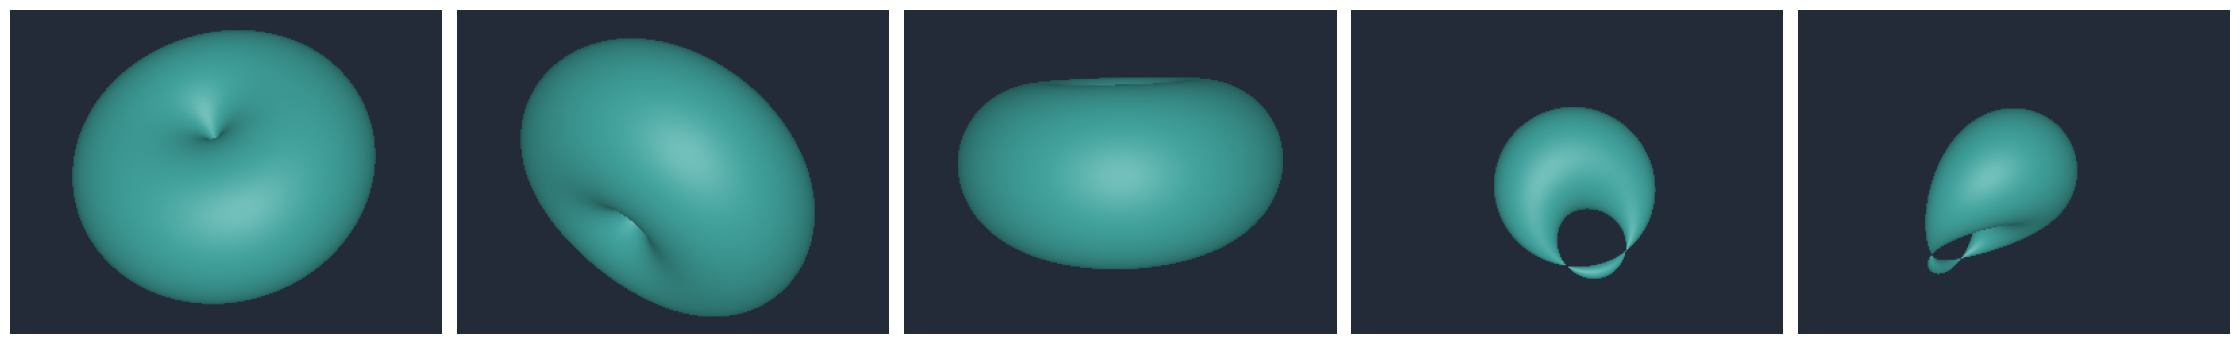

In [13]:
def orientation(angles):
    rotor = mv.rotor()
    for plane, angle in zip((mv.xy, mv.xz, mv.xw, mv.yz, mv.yw, mv.zw), angles):
        rotor = rotor * (plane * angle).exp()
    return rotor                                                             # [] Motor

def view(centre: Sphere, angles, ahead: float, yaw: float, pitch: float):
    # Turn the shape, carry its centre to `ahead` rad in front of the eye, then turn the eye onto it.
    turned = orientation(angles)
    target = mv.w * np.cos(ahead) - mv.x * np.sin(ahead)
    carry = (1 + target * (turned >> centre)).normalized()
    look = (mv.xy * (yaw / 2)).exp() * (mv.xz * (pitch / 2)).exp()
    return look * carry * turned                                             # [] Motor

# Which spindle, its orientation angles in the six planes, the distance, and the eye's yaw and pitch:
shots = [
    (0, [-0.186, -0.692, 2.658, 0.181, -0.282, -0.225], 1.10, -0.021, 0.061),
    (0, [1.124, 0.598, 0.155, 0.889, -0.164, -0.741], 1.05, -0.051, -0.062),
    (0, [0.464, 0.073, 0.536, -2.263, 0.817, -0.768], 1.05, -0.001, 0.060),
    (1, [-0.257, 0.18, 0.46, -0.999, -1.384, -0.004], 0.85, 0.137, -0.377),
    (1, [-0.511, -0.64, -0.64, 1.096, -1.168, -0.477], 0.85, -0.297, -0.358),
]
views = stack([view(midpoints[i], angles, ahead, yaw, pitch) for i, angles, ahead, yaw, pitch in shots])   # [5] Motor
shot_surfaces: Quadric = stack([spindles[i] for i, *_ in shots])            # [5] Sphere <- Point
placed_shots: Quadric = views >> shot_surfaces(views << Point)               # [5] Sphere <- Point

# Through the opening the eye sees both sides of the sheets, so the headlight takes the unsigned cosine.
facing, visible = trace(placed_shots)
render.draw_facing(facing.abs(), visible, shape);

## 7. Symmetry Instead of Degree

The cylinder is built from great spheres and `e` only. That makes its polynomial in `u` palindromic: the `u**4` and constant coefficients agree, and the `u**3` and `u` coefficients are opposite. A palindromic quartic is a quadratic in `cot(t)`, and the four hits along a great circle come in antipodal pairs. The lopsided dilation breaks that symmetry.

The degree drops only for surfaces through the antipode of the eye, where the `u**4` coefficient vanishes.

In [14]:
# The cylinder and a Dupin cyclide, both placed:
surfaces: Quadric = stack((placed[0], placed_lopsided[0]))                  # [2] Sphere <- Point
form = camera_map & surfaces(camera_map)                                     # [2] Scalar <- (Point, Point)

sample = pixels[::20000]                                                     # [4] Direction
outer_gap: Scalar = form(ray_bend, ray_bend)[:, None](sample, sample, sample, sample) - form(origin, origin)[:, None]   # [2, 4] Scalar: u**4 - constant
odd_gap: Scalar = (4 * form(ray_linear, ray_bend))[:, None](sample, sample, sample) + (4 * form(origin, ray_linear))[:, None](sample)   # [2, 4] Scalar: u**3 + u

print("u**4 - constant, for the cylinder and a Dupin cyclide:\n", outer_gap.to_array())
print("u**3 + u:\n", odd_gap.to_array())

u**4 - constant, for the cylinder and a Dupin cyclide:
 [[ 0.       -0.       -0.       -0.      ]
 [-1.089634 -1.089634 -1.089634 -1.089634]]
u**3 + u:
 [[ 0.        0.       -0.        0.      ]
 [10.74019  18.349777 15.490689 22.317394]]


## 8. Rolling a Torus Around a Circle

A circle is the meet of two spheres, a bivector, and its exponential turns points around the circle, the way a vortex ring carries fluid around its core. Around the torus's own core circle the flow only spins the tube in place and leaves the torus unchanged. Around that core tilted a little, one turn rolls and deforms the torus.

Saved /Users/eelco/development/hobby/numga/rewrite/plots/cyclides_vortex_00.gif


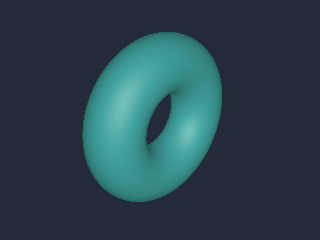

In [15]:
# The middle torus, and its core circle z ^ w carried the same way after a tilt of 0.4 rad in the yw plane:
circle = ((place[1] * (mv.yw * 0.2).exp()) >> (mv.z ^ mv.w)).restrict[2]     # [] Bivector: the meet of two great spheres
circle = circle / (-(circle * circle).select[0]).square_root()               # normalized: circle * circle == -1

# One turn around the circle over 36 frames; each frame is traced as the animation consumes it:
phases = np.linspace(0.0, 2 * np.pi, 36, endpoint=False)
flow = (circle * (phases / 2)).exp()                                          # [36] Motor
rolled: Quadric = flow >> tori[1](flow << Point)                              # [36] Sphere <- Point
traced = (trace(surface.reshape(1)) for surface in rolled)

display(Image(filename=save_animation(render.facing_frames(traced, shape), "cyclides_vortex", 60)))